# Retail_Prices_of _Products_dashboard

About Dataset
This dataset contains monthly retail price data for a wide range of consumer products sold in various Canadian provinces over several years. It has been enriched with tax, category, and classification metadata for deeper insights.
Usefulness of the Dataset
This dataset can be used for:

Use Case	Description
Price Trend Analysis	Track price movements over time, province, and product category.
Inflation Studies	Examine inflation on essentials vs non-essentials over time.
Regional Price Comparison	Analyze cost disparities for the same goods across provinces.
Tax Policy Impact	Understand how tax laws affect consumer pricing by region.
Budget Optimization	Identify high-cost vs low-cost essentials for better planning.
Machine Learning Integration	Use in models for price prediction or consumer segmentation.

Product Retail Price Survey 2017-2025
Kaggle


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv('Retail_Prices_of _Products.csv')
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars


###### │ Year             | Reference Year                                               |
###### | Month            | Reference Month                                              │
###### │ GEO              │ Geographic region (encoded as Province 1, Province 2, etc.)  │
###### │ Products         │ Name of the retail product                                   │
###### │ COORDINATE       │ Internal coordinate identifier for product                   │
###### │ VALUE            │ Original product price per unit (before tax)                 │
###### │ UOM              │ Unit of measure (e.g., Dollars)                              │
###### │ Taxable          │ 'Yes' if the product is subject to tax, 'No' otherwise       │
###### │ Total tax rate   │ Total tax rate (%) based on province or average for 'Canada' │
###### │ Value after tax  │ Price after tax if taxable, else same as VALUE               │
###### │ Product Category │ High-level category assigned to the product                  │
###### │ Essential        │ 'Essential' for basic needs or 'Non-Essential'               │

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Year              118482 non-null  int64  
 1   Month             118482 non-null  object 
 2   GEO               118482 non-null  object 
 3   Product Category  118482 non-null  object 
 4   Products          118482 non-null  object 
 5   VALUE             118482 non-null  float64
 6   Taxable           118482 non-null  object 
 7   Total tax rate    118482 non-null  float64
 8   Value after tax   118482 non-null  float64
 9   Essential         118482 non-null  object 
 10  COORDINATE        118482 non-null  float64
 11  UOM               118482 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 10.8+ MB


In [45]:
df.shape

(118482, 12)

In [46]:
df.dtypes

Year                  int64
Month                object
GEO                  object
Product Category     object
Products             object
VALUE               float64
Taxable              object
Total tax rate      float64
Value after tax     float64
Essential            object
COORDINATE          float64
UOM                  object
dtype: object

In [47]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
dtype: int64

In [164]:
df.rename(columns={
    'Year': 'Ano',
    'Month': 'Mês',
    'GEO': 'Região',
    'Products': 'Produtos',
    'COORDINATE': 'Coordenada',
    'VALUE': 'Valor',
    'UOM': 'Unidade',
    'Taxable': 'Tributável',
    'Total tax rate': 'Taxa de Imposto',
    'Value after tax': 'Valor com Imposto',
    'Product Category': 'Categoria',
    'Essential': 'Essencial'
}, inplace=True)

In [49]:
df.count()

Ano                  118482
Mês                  118482
Região               118482
Categoria            118482
Produtos             118482
Valor                118482
Tributável           118482
Taxa de Imposto      118482
Valor com Imposto    118482
Essencial            118482
Coordenada           118482
Unidade              118482
dtype: int64

In [50]:
df.describe()

,Ano,Valor,Taxa de Imposto,Valor com Imposto,Coordenada
count,118482.000000,118482.000000,118482.000000,118482.000000,118482.000000
mean,2020.591837,5.437324,12.632134,5.515499,6.501741
std,2.355363,5.192748,2.899124,5.215311,3.172173
min,2017.000000,0.300000,5.000000,0.300000,1.100000
25%,2019.000000,2.850000,11.000000,2.910000,3.750000
50%,2021.000000,3.990000,13.000000,4.050000,6.500000
75%,2023.000000,5.810000,15.000000,5.947500,9.240000
max,2025.000000,48.450000,15.000000,48.450000,11.990000


In [51]:
df['Valor'].quantile([0.25, 0.5, 0.75])

0.25    2.85
0.50    3.99
0.75    5.81
Name: Valor, dtype: float64

In [52]:
df.tail()

,Ano,Mês,Região,Categoria,Produtos,Valor,Tributável,Taxa de Imposto,Valor com Imposto,Essencial,Coordenada,Unidade
118477,2025,February,Province 11,Nuts & Snacks,"Sunflower seeds, 400 grams",4.50,No,12.0,4.50,Non-Essential,10.109,Dollars
118478,2025,February,Province 11,Toiletries & Cleaning,"Deodorant, 85 grams",8.07,Yes,12.0,9.04,Essential,10.750,Dollars
118479,2025,February,Province 11,Toiletries & Cleaning,"Toothpaste, 100 millilitres",4.13,Yes,12.0,4.63,Essential,10.760,Dollars
118480,2025,February,Province 11,Toiletries & Cleaning,"Shampoo, 400 millilitres",7.18,Yes,12.0,8.04,Essential,10.770,Dollars
118481,2025,February,Province 11,Toiletries & Cleaning,"Laundry detergent, 4.43 litres",13.19,Yes,12.0,14.77,Essential,10.110,Dollars


In [53]:
df[['Valor', 'Taxa de Imposto', 'Valor com Imposto']].corr()

,Valor,Taxa de Imposto,Valor com Imposto
Valor,1.000000,0.000722,0.998868
Taxa de Imposto,0.000722,1.000000,0.004152
Valor com Imposto,0.998868,0.004152,1.000000


In [54]:
df.groupby('Categoria')['Valor'].max()

Categoria
Beverages                  8.05
Canned & Jarred Goods      6.87
Cooking Essentials        18.04
Dairy & Eggs               9.11
Frozen Foods               5.53
Fruits                    11.46
Grains & Bakery           11.90
Infant & Baby Products    48.35
Legumes & Dry Goods        4.57
Meat & Poultry            48.45
Nuts & Snacks              6.54
Other                      1.57
Toiletries & Cleaning     19.62
Vegetables                10.87
Name: Valor, dtype: float64

In [55]:
df.groupby('Categoria')['Valor'].min()

Categoria
Beverages                 2.95
Canned & Jarred Goods     0.62
Cooking Essentials        1.38
Dairy & Eggs              1.61
Frozen Foods              2.19
Fruits                    0.57
Grains & Bakery           1.69
Infant & Baby Products    1.09
Legumes & Dry Goods       1.72
Meat & Poultry            1.30
Nuts & Snacks             2.56
Other                     0.30
Toiletries & Cleaning     2.20
Vegetables                0.88
Name: Valor, dtype: float64

In [56]:
df.groupby('Categoria')['Valor'].apply(np.ptp)

Categoria
Beverages                  5.10
Canned & Jarred Goods      6.25
Cooking Essentials        16.66
Dairy & Eggs               7.50
Frozen Foods               3.34
Fruits                    10.89
Grains & Bakery           10.21
Infant & Baby Products    47.26
Legumes & Dry Goods        2.85
Meat & Poultry            47.15
Nuts & Snacks              3.98
Other                      1.27
Toiletries & Cleaning     17.42
Vegetables                 9.99
Name: Valor, dtype: float64

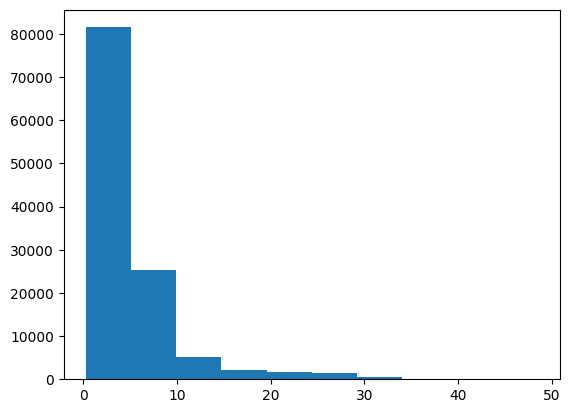

In [73]:
counts, bins = np.histogram(df['Valor'], bins=10)
plt.hist(df['Valor'], bins=10)
plt.show()

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ano                118482 non-null  int64  
 1   Mês                118482 non-null  object 
 2   Região             118482 non-null  object 
 3   Categoria          118482 non-null  object 
 4   Produtos           118482 non-null  object 
 5   Valor              118482 non-null  float64
 6   Tributável         118482 non-null  object 
 7   Taxa de Imposto    118482 non-null  float64
 8   Valor com Imposto  118482 non-null  float64
 9   Essencial          118482 non-null  object 
 10  Coordenada         118482 non-null  float64
 11  Unidade            118482 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 10.8+ MB


In [78]:
df.groupby('Categoria')['Essencial'].value_counts()

Categoria               Essencial    
Beverages               Non-Essential     2156
Canned & Jarred Goods   Essential         6468
                        Non-Essential     4312
Cooking Essentials      Essential         6468
Dairy & Eggs            Essential        11760
Frozen Foods            Non-Essential     4312
Fruits                  Essential        15092
Grains & Bakery         Essential         8624
                        Non-Essential     2156
Infant & Baby Products  Essential         2156
Legumes & Dry Goods     Essential         3234
Meat & Poultry          Essential        18326
                        Non-Essential     2156
Nuts & Snacks           Non-Essential     3234
Other                   Non-Essential     1078
Toiletries & Cleaning   Essential         4312
Vegetables              Essential        21560
                        Non-Essential     1078
Name: count, dtype: int64

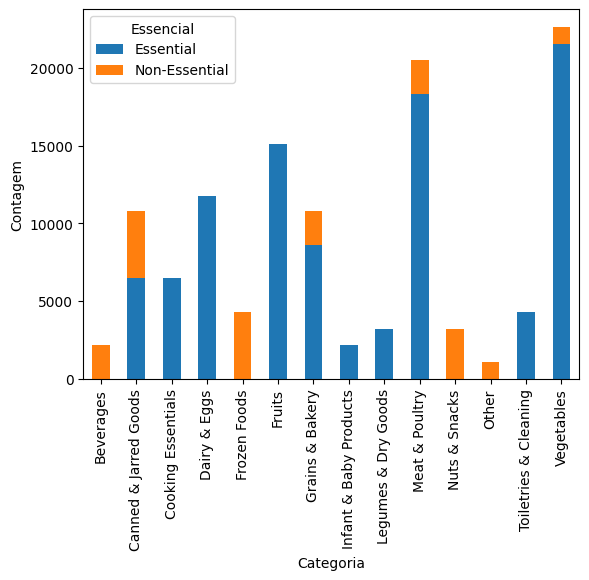

In [79]:
counts = df.groupby('Categoria')['Essencial'].value_counts().unstack()
counts.plot(kind='bar', stacked=True)
plt.xlabel('Categoria')
plt.ylabel('Contagem')
plt.show()

In [92]:
df.groupby('Mês')['Valor'].sum()

Mês
April        52006.39
August       52928.30
December     52887.64
February     59167.67
January      59096.82
July         53354.68
June         53167.09
March        51668.11
May          52946.72
November     53018.63
October      51664.87
September    52318.07
Name: Valor, dtype: float64

In [ ]:
mes_para_num = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}
df['Data_Formatada'] = df['Mês'].map(mes_para_num) + '/' + df['Ano'].astype(str)
df.head()

,Ano,Mês,Região,Categoria,Produtos,Valor,Tributável,Taxa de Imposto,Valor com Imposto,Essencial,Coordenada,Unidade,Data,Data_Formatada
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars,2017-01-01,01/2017
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars,2017-01-01,01/2017
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars,2017-01-01,01/2017
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars,2017-01-01,01/2017
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars,2017-01-01,01/2017


In [111]:
df.groupby('Categoria')['Unidade'].value_counts()

Categoria               Unidade
Beverages               Dollars     2156
Canned & Jarred Goods   Dollars    10780
Cooking Essentials      Dollars     6468
Dairy & Eggs            Dollars    11760
Frozen Foods            Dollars     4312
Fruits                  Dollars    15092
Grains & Bakery         Dollars    10780
Infant & Baby Products  Dollars     2156
Legumes & Dry Goods     Dollars     3234
Meat & Poultry          Dollars    20482
Nuts & Snacks           Dollars     3234
Other                   Dollars     1078
Toiletries & Cleaning   Dollars     4312
Vegetables              Dollars    22638
Name: count, dtype: int64

In [107]:
beverages_counts = df[df['Categoria'] == 'Beverages']['Produtos'].value_counts()
print(beverages_counts)

Produtos
Roasted or ground coffee, 340 grams    1078
Tea (20 bags)                          1078
Name: count, dtype: int64


In [113]:
canned_counts = df[df['Categoria'] == 'Canned & Jarred Goods']['Produtos'].value_counts()
print(canned_counts)

Produtos
Frozen green beans, 750 grams                1078
Mayonnaise, 890 millilitres                  1078
Canned baked beans, 398 millilitres          1078
Canned soup, 284 millilitres                 1078
Canned beans and lentils, 540 millilitres    1078
Canned corn, 341 millilitres                 1078
Canned peach, 398 millilitres                1078
Dry beans and legumes, 900 grams             1078
Salsa, 418 millilitres                       1078
Salad dressing, 475 millilitres              1078
Name: count, dtype: int64


In [ ]:
canned_counts = df[df['Categoria'] == 'Canned & Jarred Goods']['Produtos'].value_counts()
print(canned_counts)

In [ ]:
cooking_counts = df[df['Categoria'] == 'Cooking Essentials']['Produtos'].value_counts()
print(cooking_counts)

#Cooking Essentials
#Cooking_Essentials

Produtos
Margarine, 907 grams        1078
White sugar, 2 kilograms    1078
Ketchup, 1 litre            1078
Vegetable oil, 3 litres     1078
Canola oil, 3 litres        1078
Olive oil, 1 litre          1078
Name: count, dtype: int64


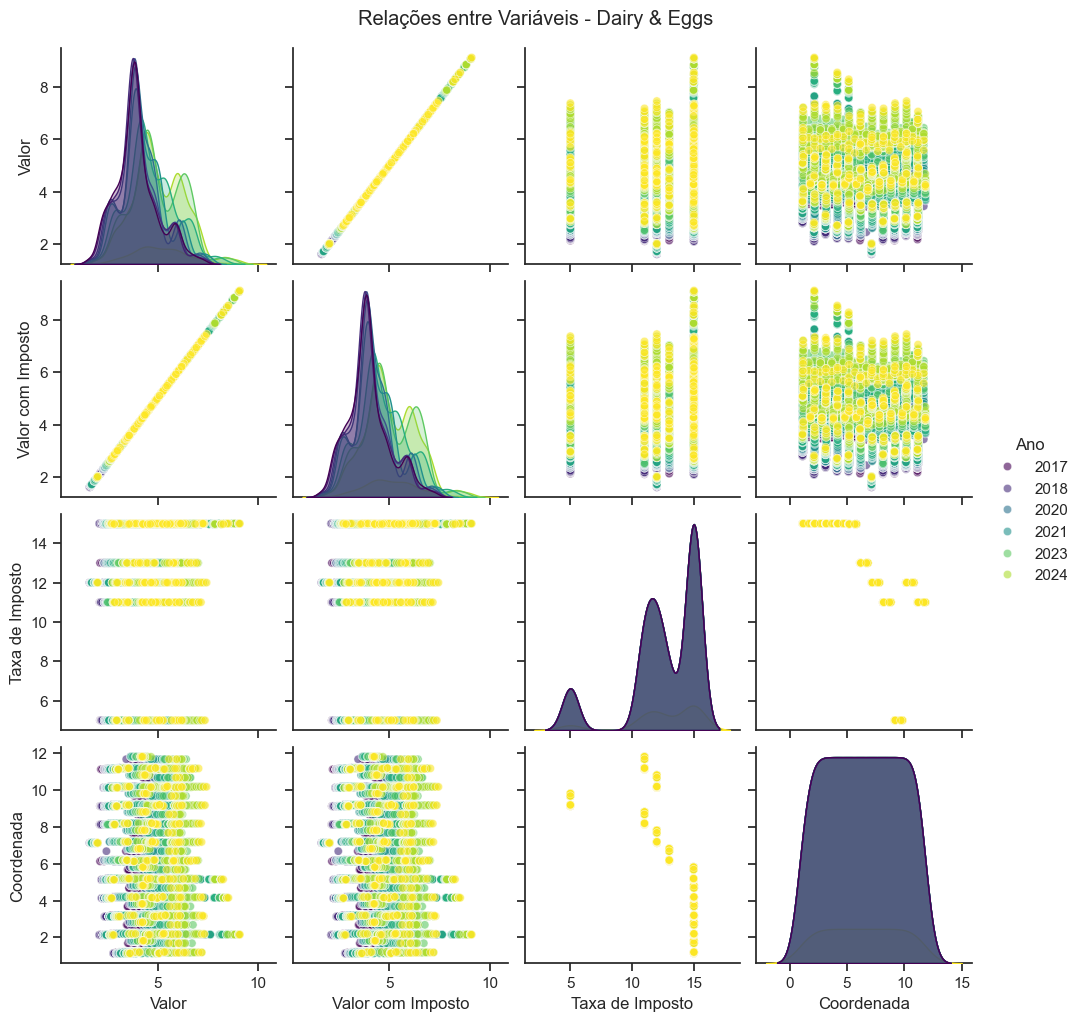

In [121]:
dairy_eggs_df = df[df['Categoria'] == 'Dairy & Eggs']

cols_numericas = ['Valor', 'Valor com Imposto', 'Taxa de Imposto', 'Coordenada']

sns.set_theme(style="ticks")
sns.pairplot(
    dairy_eggs_df[cols_numericas + ['Ano']],
    hue='Ano',
    palette='viridis',
    plot_kws={'alpha': 0.6}
)
plt.suptitle("Relações entre Variáveis - Dairy & Eggs", y=1.02)
plt.show()

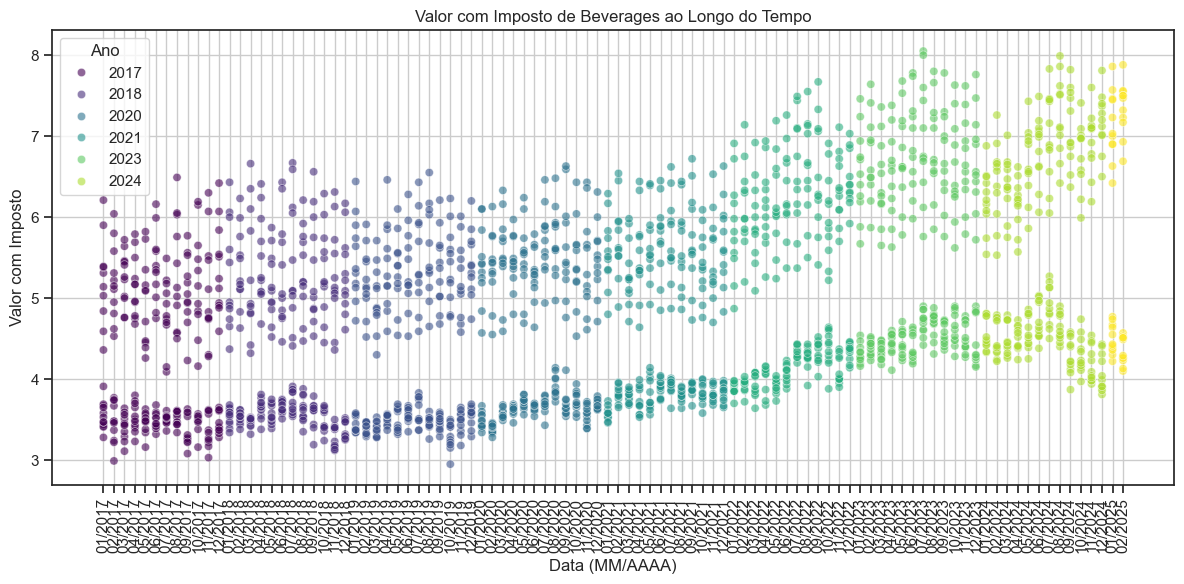

In [122]:
beverages_df = df[df['Categoria'] == 'Beverages']

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=beverages_df,
    x='Data_Formatada',
    y='Valor com Imposto',
    alpha=0.6,
    hue='Ano',
    palette='viridis'
)
plt.title("Valor com Imposto de Beverages ao Longo do Tempo")
plt.xlabel("Data (MM/AAAA)")
plt.ylabel("Valor com Imposto")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

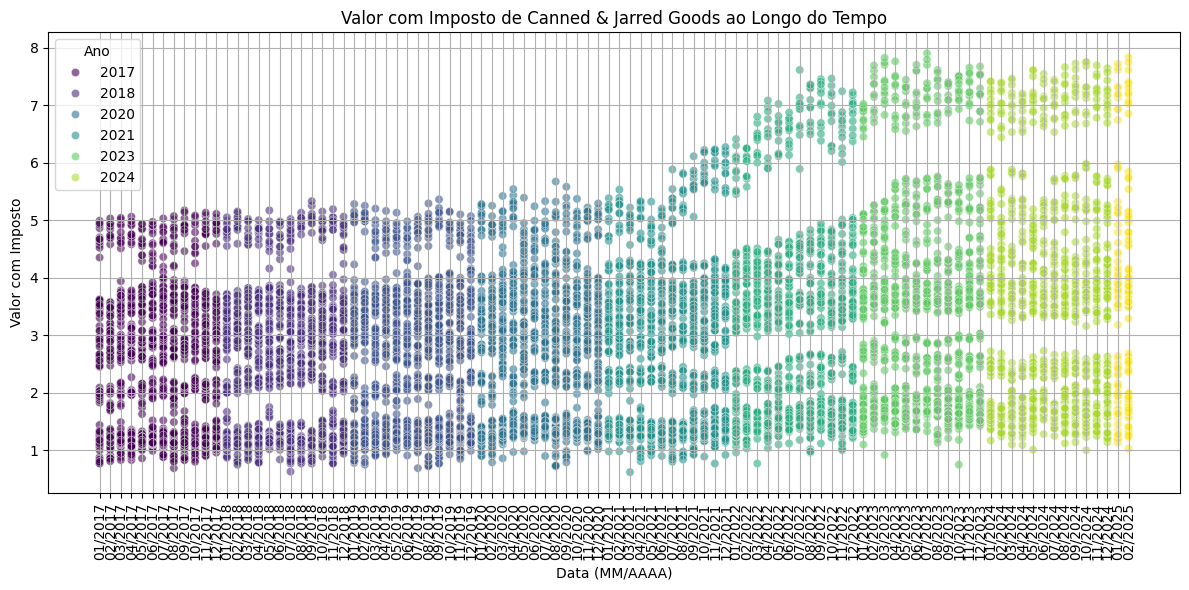

In [ ]:
Canned_Jarred_Goods_df = df[df['Categoria'] == 'Canned & Jarred Goods']
#Canned_Jarred_Goods
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=Canned_Jarred_Goods_df,
    x='Data_Formatada',
    y='Valor com Imposto',
    alpha=0.6,
    hue='Ano',
    palette='viridis'
)
plt.title("Valor com Imposto de Canned & Jarred Goods ao Longo do Tempo")
plt.xlabel("Data (MM/AAAA)")
plt.ylabel("Valor com Imposto")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

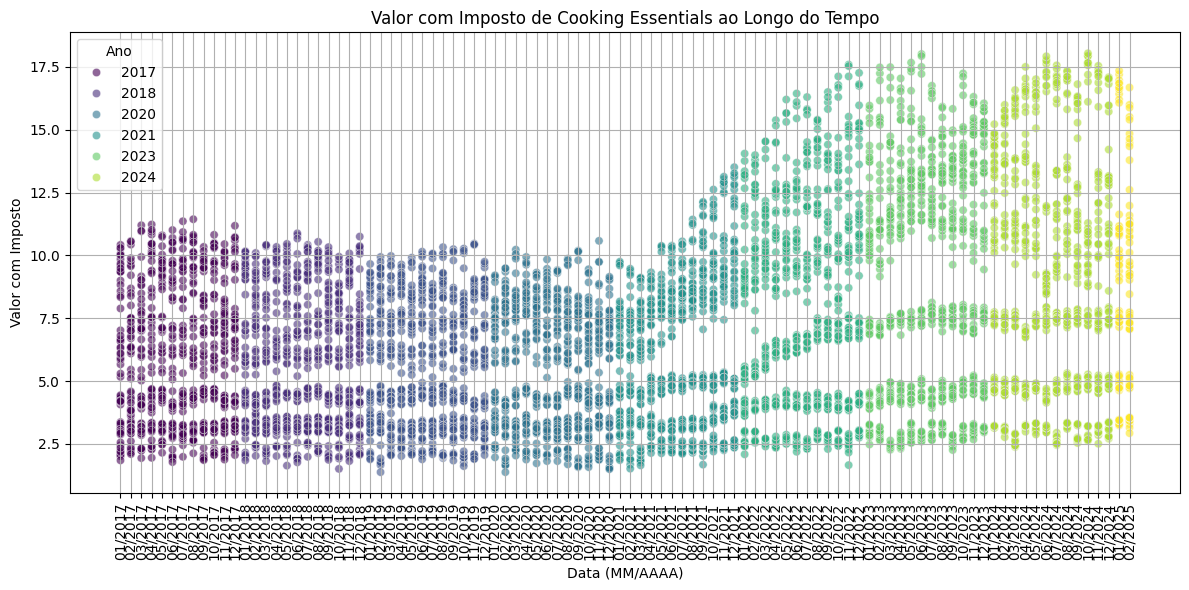

In [ ]:
Cooking_Essentials_df = df[df['Categoria'] == 'Cooking Essentials']
# Cooking_Essentials
# Cooking_Essentials
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data= Cooking_Essentials_df,
    x='Data_Formatada',
    y='Valor com Imposto',
    alpha=0.6,
    hue='Ano',
    palette='viridis'
)
plt.title("Valor com Imposto de Cooking Essentials ao Longo do Tempo")
plt.xlabel("Data (MM/AAAA)")
plt.ylabel("Valor com Imposto")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

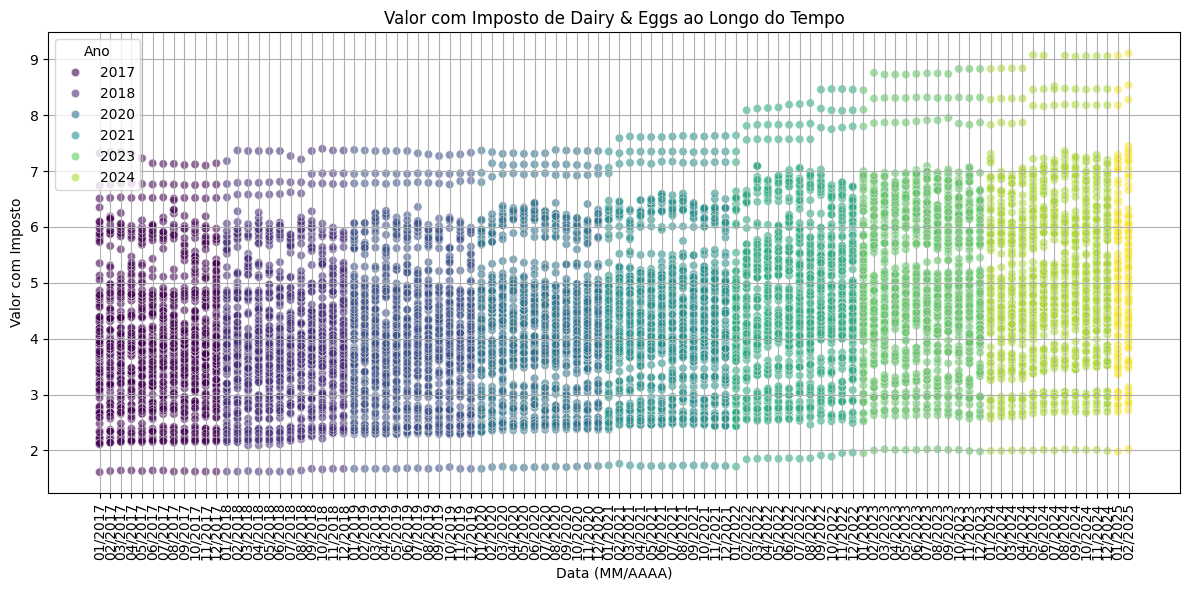

In [ ]:
# Dairy & Eggs

Dairy_Eggs_df = df[df['Categoria'] == 'Dairy & Eggs']
# Dairy_Eggs
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data= Dairy_Eggs_df,
    x='Data_Formatada',
    y='Valor com Imposto',
    alpha=0.6,
    hue='Ano',
    palette='viridis'
)
plt.title("Valor com Imposto de Dairy & Eggs ao Longo do Tempo")
plt.xlabel("Data (MM/AAAA)")
plt.ylabel("Valor com Imposto")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [130]:
lista_categorias = df[
    ((df['Categoria'] == 'Beverages')) & 
    (df['Essencial'] == 'Non-Essential')
]['Produtos'].unique()

print("Produtos Non-Essential em Beverages e Canned & Jarred Goods:")
for produto in lista_categorias:
    print(f"- {produto}")

print(f"\nTotal: {len(lista_categorias)} produtos")


Produtos Non-Essential em Beverages e Canned & Jarred Goods:
- Roasted or ground coffee, 340 grams
- Tea (20 bags)

Total: 2 produtos


In [133]:
lista_categorias = df[
    ((df['Categoria'] == 'Beverages')) & 
    (df['Essencial'] == 'Essential')
]['Produtos'].unique()

print("Produtos Non-Essential em Beverages:")
for produto in lista_categorias:
    print(f"- {produto}")

print(f"\nTotal: {len(lista_categorias)} produtos")

Produtos Non-Essential em Beverages:

Total: 0 produtos


In [132]:
lista_categorias = df[
    ((df['Categoria'] == 'Beverages')) & 
    (df['Essencial'] == 'Essential')
]['Produtos'].unique()

print("Produtos Non-Essential em Beverages:")
for produto in lista_categorias:
    print(f"- {produto}")

print(f"\nTotal: {len(lista_categorias)} produtos")

Produtos Non-Essential em Beverages:

Total: 0 produtos


In [137]:
# Meat & Poultry

lista11_categorias = df[
    ((df['Categoria'] == 'Meat & Poultry')) & 
    (df['Essencial'] == 'Essential')
]['Produtos'].unique()

print("Produtos Non-Essential em Meat & Poultry:")
for produto in lista_categorias:
    print(f"- {produto}")

print(f"\nTotal: {len(lista_categorias)} produtos")

Produtos Non-Essential em Meat & Poultry:

Total: 0 produtos


In [139]:
#Vegetables 

# Vegetables Essential Products
vegetables_essential = df[
    (df['Categoria'] == 'Vegetables') & 
    (df['Essencial'] == 'Essential')
]['Produtos'].unique()

print("Produtos Essential em Vegetables:")
for produto in vegetables_essential:
    print(f"- {produto}")

print(f"\nTotal: {len(vegetables_essential)} produtos")

Produtos Essential em Vegetables:
- Potatoes, 4.54 kilograms
- Potatoes, per kilogram
- Sweet potatoes, per kilogram
- Tomatoes, per kilogram
- Cabbage, per kilogram
- Carrots, 1.36 kilograms
- Onions, per kilogram
- Onions, 1.36 kilograms
- Celery, unit
- Cucumber, unit
- Mushrooms, 227 grams
- Iceberg lettuce, unit
- Romaine lettuce, unit
- Broccoli, unit
- Peppers, per kilogram
- Squash, per kilogram
- Salad greens, 142 grams
- Frozen french fried potatoes, 750 grams
- Frozen broccoli, 500 grams
- Canned tomatoes, 796 millilitres

Total: 20 produtos


In [140]:
#Vegetables 

# Vegetables Non-Essential Products
vegetables_essential = df[
    (df['Categoria'] == 'Vegetables') & 
    (df['Essencial'] == 'Non-Essential')
]['Produtos'].unique()

print("Produtos Non-Essential em Vegetables:")
for produto in vegetables_essential:
    print(f"- {produto}")

print(f"\nTotal: {len(vegetables_essential)} produtos")

Produtos Non-Essential em Vegetables:
- Frozen spinach, 300 grams

Total: 1 produtos


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Ano                118482 non-null  int64         
 1   Mês                118482 non-null  object        
 2   Região             118482 non-null  object        
 3   Categoria          118482 non-null  object        
 4   Produtos           118482 non-null  object        
 5   Valor              118482 non-null  float64       
 6   Tributável         118482 non-null  object        
 7   Taxa de Imposto    118482 non-null  float64       
 8   Valor com Imposto  118482 non-null  float64       
 9   Essencial          118482 non-null  object        
 10  Coordenada         118482 non-null  float64       
 11  Unidade            118482 non-null  object        
 12  Data               118482 non-null  datetime64[ns]
 13  Data_Formatada     118482 non-null  object  

In [143]:
df.head()

,Ano,Mês,Região,Categoria,Produtos,Valor,Tributável,Taxa de Imposto,Valor com Imposto,Essencial,Coordenada,Unidade,Data,Data_Formatada
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars,2017-01-01,01/2017
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars,2017-01-01,01/2017
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars,2017-01-01,01/2017
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars,2017-01-01,01/2017
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars,2017-01-01,01/2017


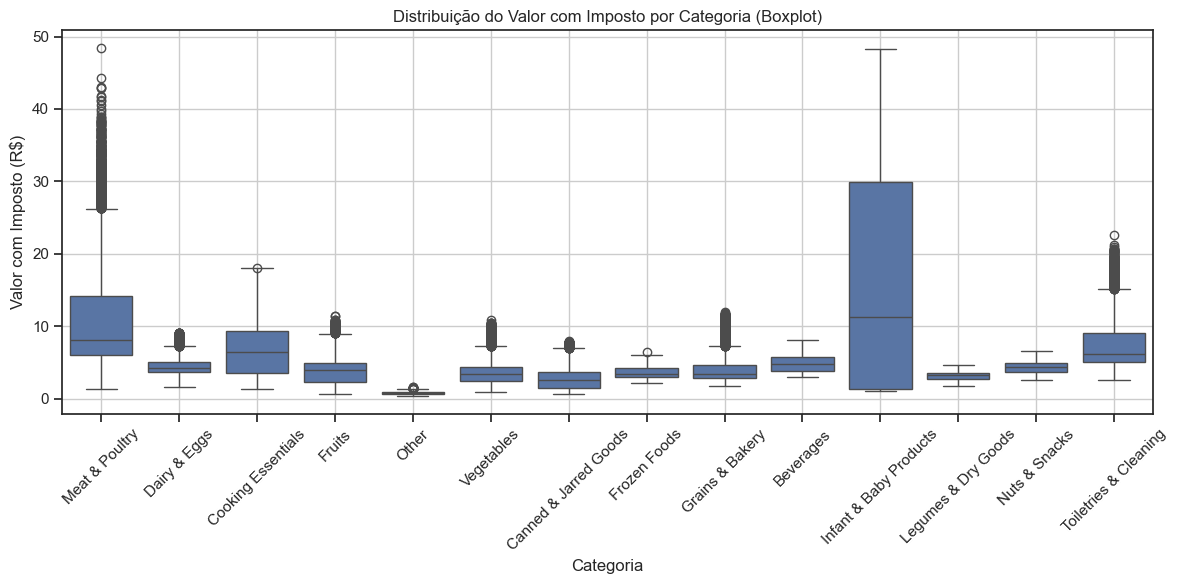

In [160]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=df['Categoria'],
    y=df['Valor com Imposto'],
)
plt.title('Distribuição do Valor com Imposto por Categoria (Boxplot)')
plt.xlabel('Categoria')
plt.ylabel('Valor com Imposto (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

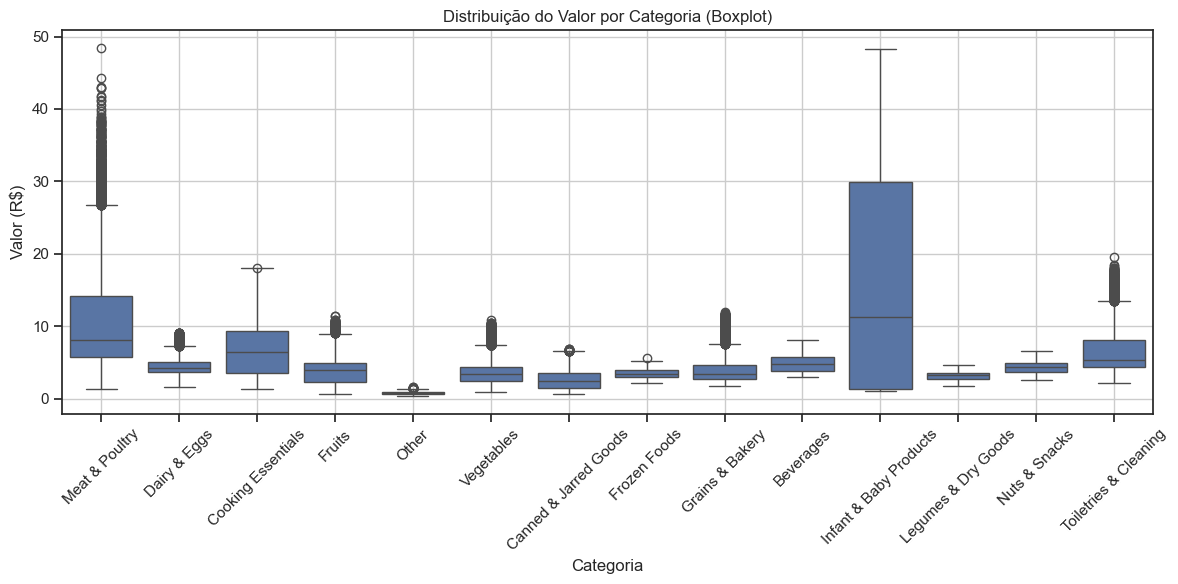

In [161]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=df['Categoria'],
    y=df['Valor'],
)
plt.title('Distribuição do Valor por Categoria (Boxplot)')
plt.xlabel('Categoria')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

C:\Users\Vithorio\AppData\Local\Temp\ipykernel_16212\2767941220.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


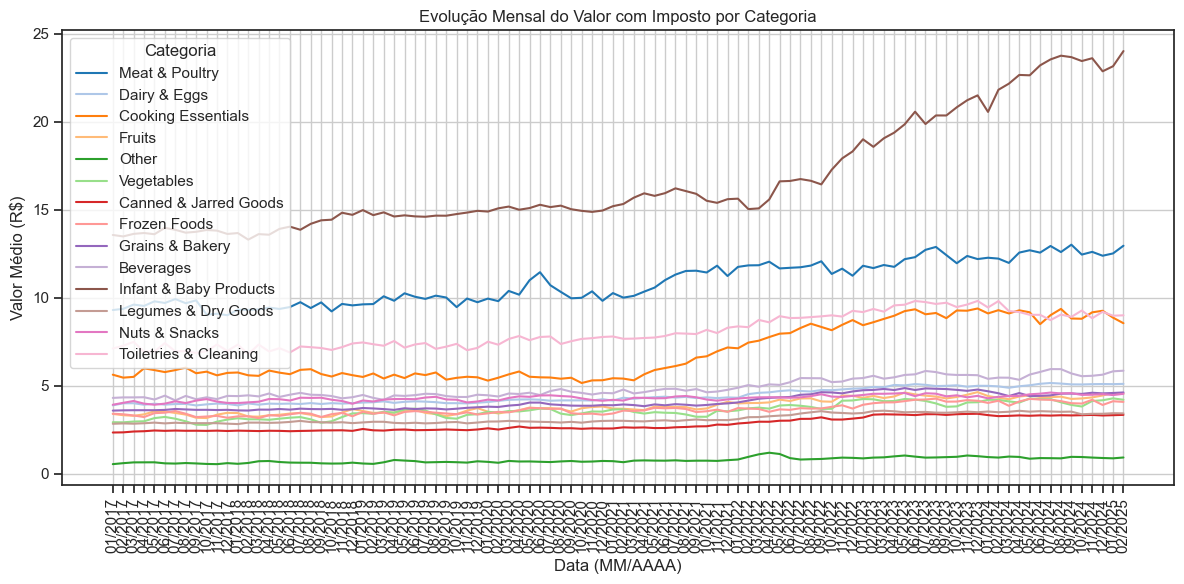

In [173]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='Data_Formatada',
    y='Valor com Imposto',
    hue='Categoria',
    estimator='mean',
    ci=None,
    palette='tab20'
)
plt.title('Evolução Mensal do Valor com Imposto por Categoria')
plt.xlabel('Data (MM/AAAA)')
plt.ylabel('Valor Médio (R$)')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

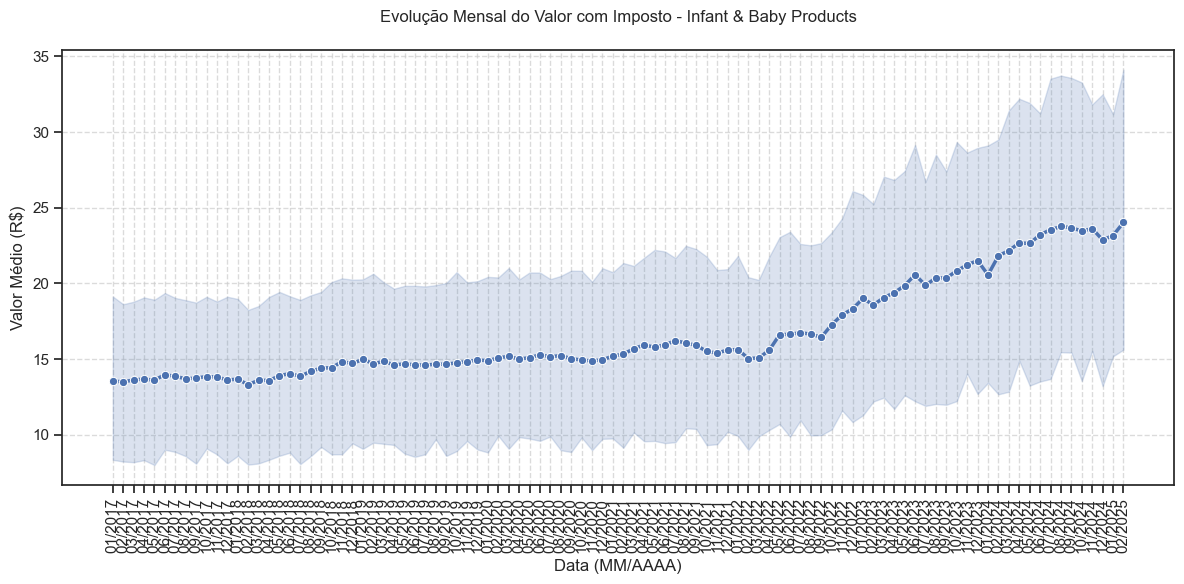

In [181]:
plt.figure(figsize=(12, 6))
df_infant = df[df['Categoria'] == 'Infant & Baby Products']

sns.lineplot(
    data=df_infant,
    x='Data_Formatada',
    y='Valor com Imposto',
    estimator='mean',
    marker='o',
    linewidth=2.5
)

plt.title('Evolução Mensal do Valor com Imposto - Infant & Baby Products', pad=20)
plt.xlabel('Data (MM/AAAA)')
plt.ylabel('Valor Médio (R$)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()